In [22]:
import pandas as pd
import numpy as np
import statsmodels as sm
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.tsa.arima.model import ARIMA
import warnings
from scipy.special import inv_boxcox

In [23]:
import statsmodels.api as sm
data=sm.datasets.sunspots.load_pandas().data
data.head(5)

,YEAR,SUNACTIVITY
0,1700.0,5.0
1,1701.0,11.0
2,1702.0,16.0
3,1703.0,23.0
4,1704.0,36.0


In [24]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         309 non-null    float64
 1   SUNACTIVITY  309 non-null    float64
dtypes: float64(2)
memory usage: 5.0 KB


In [25]:
(data.isna()|data.isnull()|(data==" ")|(data=="  ")).sum()

YEAR           0
SUNACTIVITY    0
dtype: int64

In [26]:
data["YEAR"]=data["YEAR"].astype(int)
# data=df.copy()
# df["YEAR"]=pd.to_datetime(df["YEAR"],format="%Y") 
# df["Y"]=df["YEAR"].dt.year
#train data
df=data.iloc[0:287,:]
#test data
testdf=data.iloc[287:,:]

In [27]:
def plottrend(df):
    plt.figure(figsize=(15,5))
    plt.plot(df['YEAR'],df.iloc[:,-1])
    plt.xticks(np.arange(df['YEAR'].min(), df['YEAR'].max() + 1, 11))
    plt.grid(True,linestyle="--",alpha=0.4)
    plt.title("sunspots")
    plt.ylabel(df.columns[-1])
    plt.xticks(rotation=90,ha='center')
    plt.xlim(df['YEAR'].min()-11,df['YEAR'].max()+11)
    plt.show()

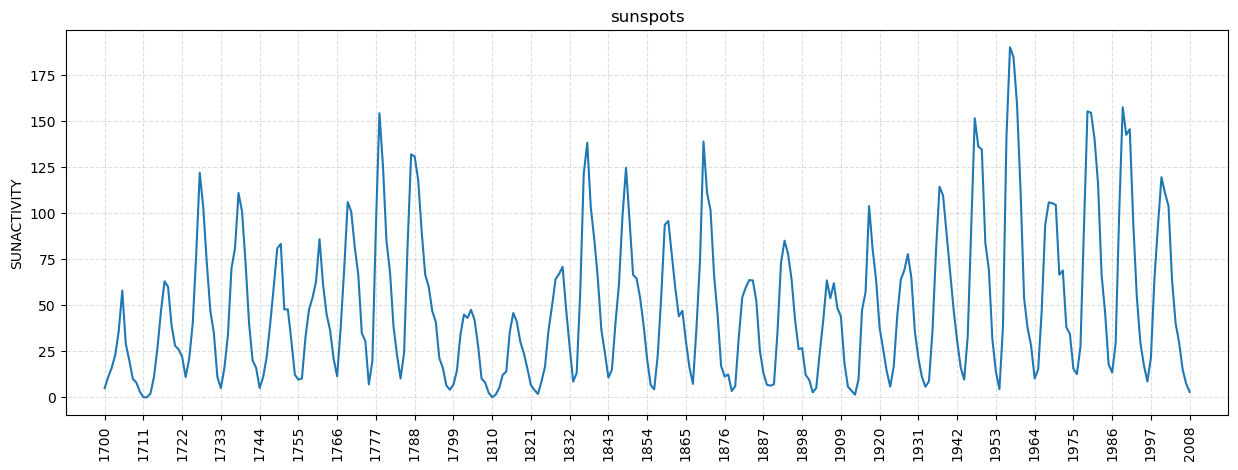

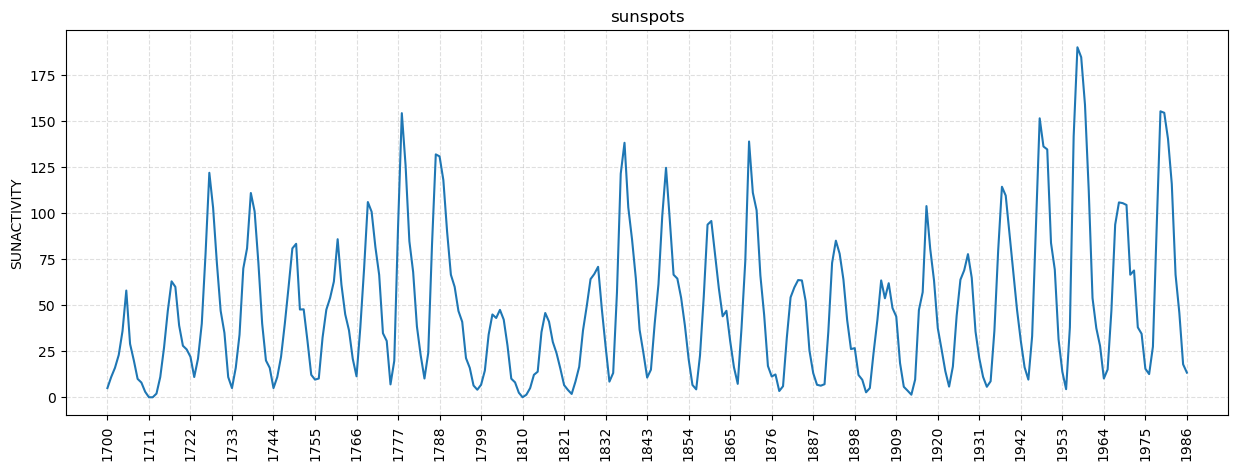

In [28]:
plottrend(data)
plottrend(df)

As we can see from plot,Sun activity has high variance. Some of values are zero . so log transformation wont be suitable. We apply Box-Cox transformation.

In [29]:
#Modiification in Test data
df["trans_activity"],l=stats.boxcox(df["SUNACTIVITY"]+1)
print(f"Optimal lambda is {l}")
df.head()

Optimal lambda is 0.31609840512174947


,YEAR,SUNACTIVITY,trans_activity
0,1700,5.0,2.410211
1,1701,11.0,3.775560
2,1702,16.0,4.583198
3,1703,23.0,5.475364
4,1704,36.0,6.742096


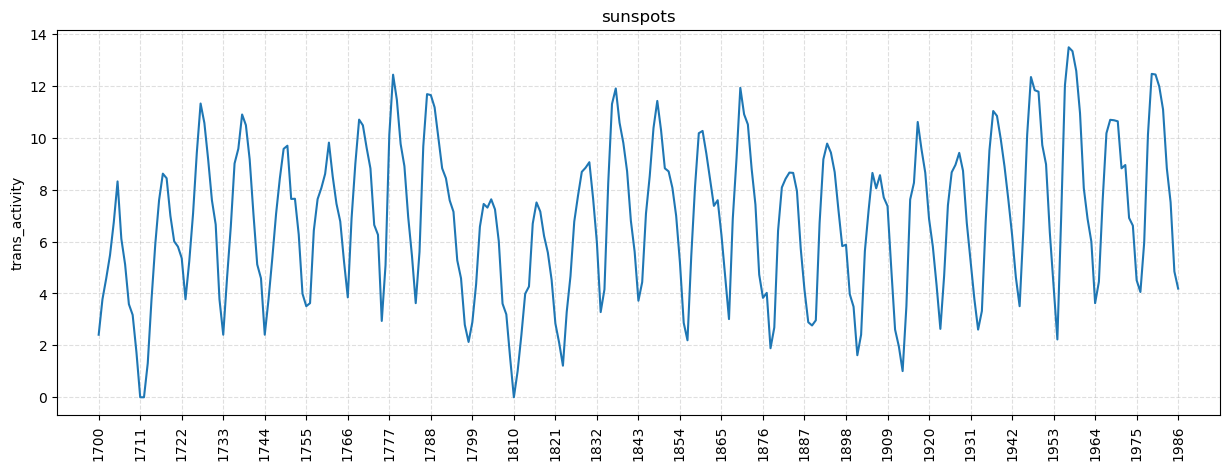

In [30]:
plottrend(df)

In [31]:
#Removing seasonality of 11 years
df['Removeseasonal']=df['trans_activity'].diff(periods=11)
df=df.dropna()

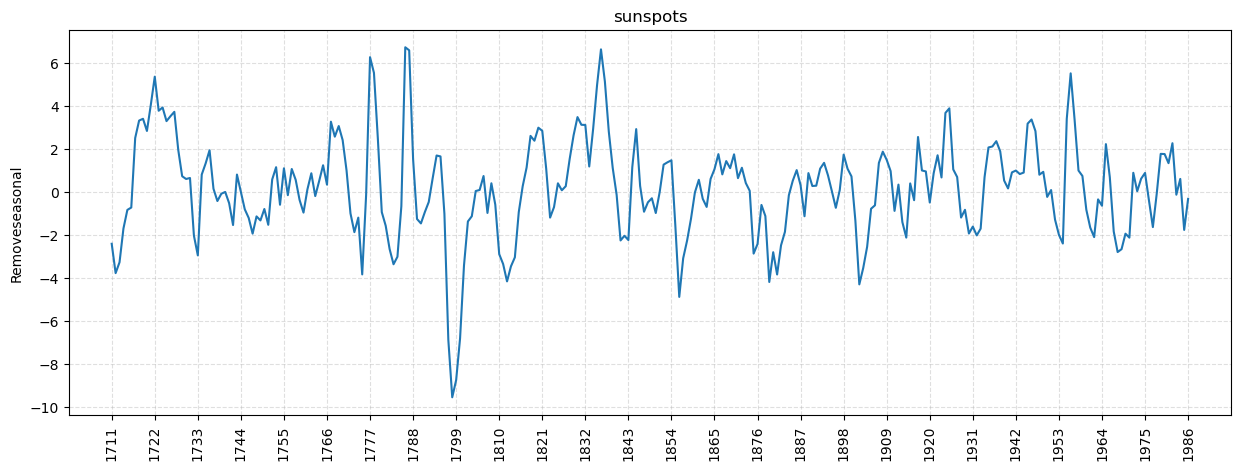

In [32]:
plottrend(df)

In [33]:
#Check stationery of noise
def check_stationery(ser):
    adstat,pvalue,*_=adfuller(ser)
    print(f"The test statistics is {adstat:.4f}")
    print(f"The Pvalue is {pvalue:.4f}")
    if pvalue>0.05:
        print("Noise is not stationery")
    else:
        print("Noise is stationery")
def verify_stationery(ser):
    #check rolling mean and rolling variance
    rmean=ser.rolling(window=11).mean()
    rvar=ser.rolling(window=11).std()
    #plot acf,pacf,rolling mean and and rolling variance
    fig,ax=plt.subplots(2,2,figsize=(15,10))
    plot_acf(ser,lags=44,ax=ax[0,0])
    plot_pacf(ser,lags=44,ax=ax[0,1])
    ax[1,0].plot(rmean,label="Rolling mean",color="red")
    ax[1,0].set_title("Rolling Mean")
    ax[1,1].plot(rvar,label="Rolling variance",color="blue")
    ax[1,1].set_title("Rolling Variance")
    plt.savefig('acfandpacf.png',dpi=300)
    plt.show()

The test statistics is -3.6148
The Pvalue is 0.0055
Noise is stationery


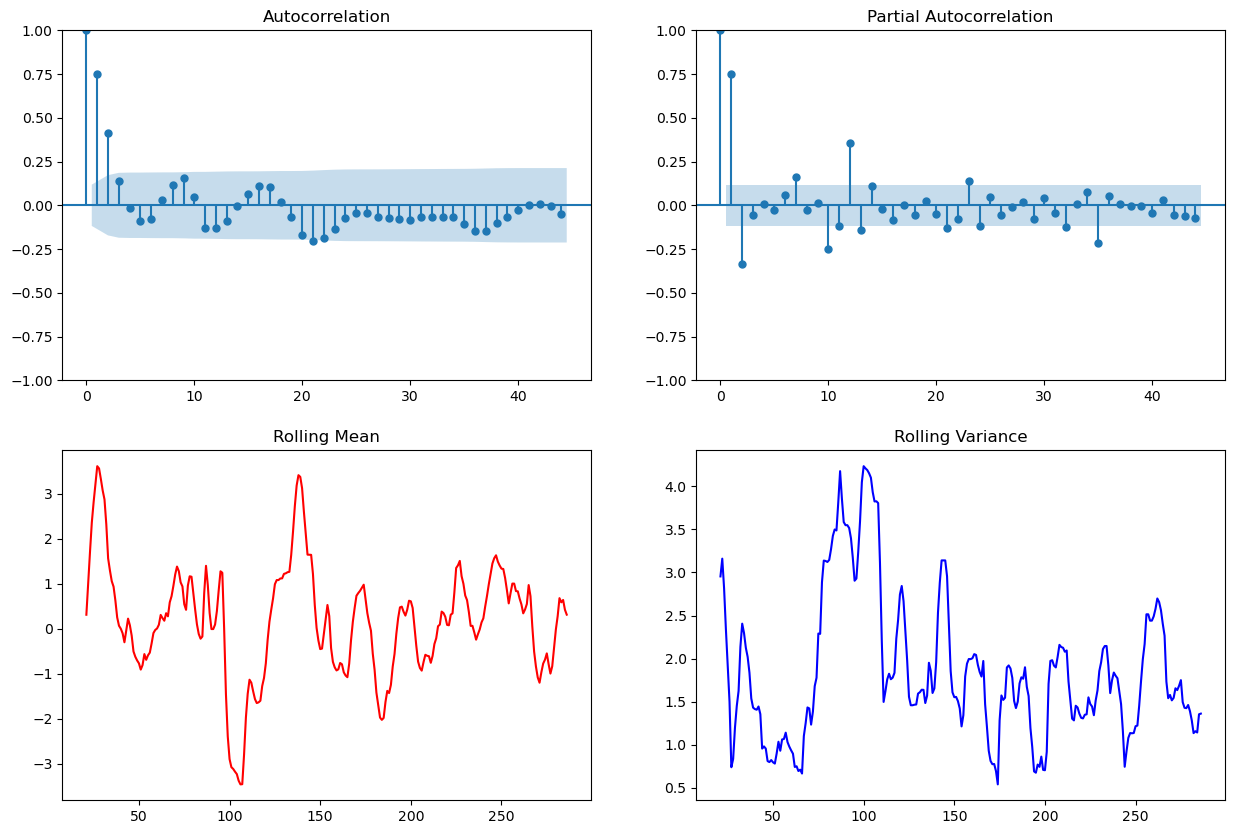

In [34]:
check_stationery(df['Removeseasonal'])
verify_stationery(df['Removeseasonal'])

Judging from nature of acf and pacf plot, AR model is best suited. Pacf has sharp cutoff after lag 2. AR(2) is best model by visual inspection of Plots.

In [35]:
#Searching for best model using grid search
warnings.filterwarnings("ignore")
pvalue = range(0, 4)
dvalue = range(0,4)
qvalue = range(0, 4)
low_aic, best_order = float("inf"), None
for p in pvalue:
    for d in dvalue:
        for q in qvalue:
            order = (p, d, q)  
            try:
                model_fit = ARIMA(df["Removeseasonal"], order=order).fit()
                aic = model_fit.aic
                if aic < low_aic:
                    low_aic = aic
                    best_order = order
            except:
                continue
            
print(f"The best model is of order {best_order}")
        

The best model is of order (2, 0, 0)


In [36]:
#Fitting AR(2) Model 
model=ARIMA(df["Removeseasonal"],order=(2,0,0)).fit()
print(model.summary())
# model.plot_diagnostics(figsize=(10,8))


                               SARIMAX Results                                
Dep. Variable:         Removeseasonal   No. Observations:                  276
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -492.375
Date:                Mon, 01 Jun 2026   AIC                            992.750
Time:                        09:34:12   BIC                           1007.231
Sample:                             0   HQIC                           998.561
                                - 276                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1534      0.270      0.568      0.570      -0.376       0.683
ar.L1          1.0019      0.054     18.513      0.000       0.896       1.108
ar.L2         -0.3352      0.058     -5.754      0.0

The p-value of Ljung-Box test(0.91>0.05) and Heteroskedasticity test(0.22>0.05) is insignificant,it confirms residuals are white noise with variance constant over time. But Jarque-Bera test(0.00<0.05) says the residual is not normally distributed ,because of high kurtosis.

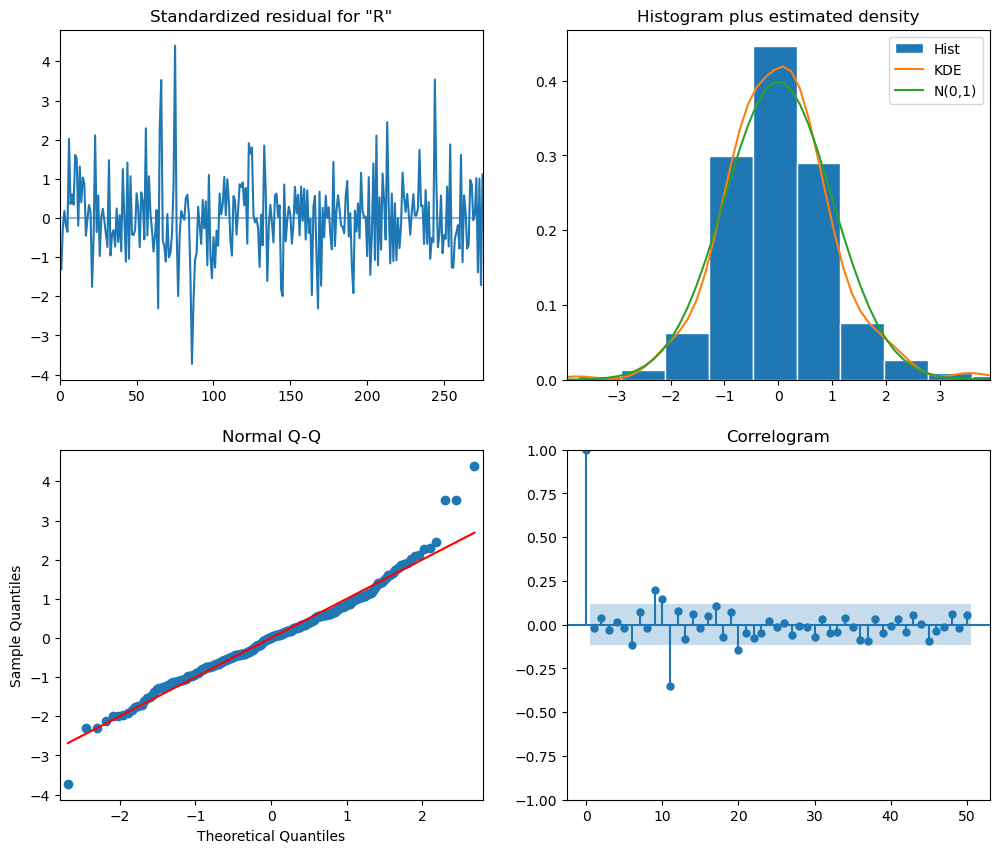

In [37]:
model.plot_diagnostics(figsize=(12,10),lags=50);
plt.savefig("residualplot.png",dpi=300)

Standarized residual for "R" is constant over time,proving model is unbiased. The standarized residual plot follows a normal distribution but exhibit heavy tails, as shown in Q-Q curve. Beacuse of these heavy tails,JB test mathematically concluded the residual is not normally distributed. Except for lag 0, the correlation of residual at any lag is inside threshold,which coforms our model captures perfectly caputered the relation of data , leaving behing white noise. We ignore 4 points at heavy tails and huge spike at lag 11 due to some noise. We move forward eith AR(2) model for forecasting. 

In [38]:
#forecasting
forecast=model.get_forecast(steps=22)
forecast_mean=forecast.predicted_mean
conf_int=forecast.conf_int()
print(forecast_mean.head(5))
print(conf_int.head(5))

287    0.319319
288    0.479384
289    0.424393
290    0.315649
291    0.225131
Name: predicted_mean, dtype: float64
     lower Removeseasonal  upper Removeseasonal
287             -2.498655              3.137293
288             -3.509600              4.468369
289             -3.987179              4.835965
290             -4.195251              4.826550
291             -4.296525              4.746787


In [39]:
#Adding back seasonality
hist_seasonal=list(df["trans_activity"].iloc[-11:]) #adding 11 data from original transformed data
lower_seasonal=hist_seasonal.copy()
upper_seasonal=hist_seasonal.copy()
print(hist_seasonal)
for i in range(22):
    #adding seasonal to prediction mean
    forecast_mean.iloc[i]=forecast_mean.iloc[i]+hist_seasonal[i]
    hist_seasonal.append(forecast_mean.iloc[i])
    #adding seasonal to lower confidence interval
    conf_int.iloc[i,0]=conf_int.iloc[i,0]+lower_seasonal[i]
    lower_seasonal.append(conf_int.iloc[i,0])
    #adding seasonal to Higher confidence interval
    conf_int.iloc[i,1]=conf_int.iloc[i,1]+upper_seasonal[i]
    upper_seasonal.append(conf_int.iloc[i,1])
    
print(forecast_mean.head(5))
print(conf_int.head(5))

[4.055602649603876, 5.95762519312883, 10.11490020930262, 12.459715967389164, 12.434410805242905, 11.969647445988695, 11.086287115024595, 8.8209560092543, 7.513023125432554, 4.847031698727367, 4.187221854926953]
287     4.374922
288     6.437009
289    10.539293
290    12.775365
291    12.659542
Name: predicted_mean, dtype: float64
     lower Removeseasonal  upper Removeseasonal
287              1.556948              7.192896
288              2.448025             10.425994
289              6.127722             14.950865
290              8.264465             17.286266
291              8.137886             17.181198


In [40]:
#Retransforming to original Scale
#clipping to prevent negative bases
final_forecast=np.clip(forecast_mean,(-1/l)+1e-5,None)
lowerci_forecast=np.clip(conf_int.iloc[:,0],(-1/l)+1e-5,None)
upperci_forecast=np.clip(conf_int.iloc[:,1],(-1/l)+1e-5,None)
#Coverting to original scale by using inverse boxcox
final_forecast=inv_boxcox(final_forecast,l)-1
lowerci_forecast=inv_boxcox(lowerci_forecast,l)-1
upperci_forecast=inv_boxcox(upperci_forecast,l)-1
#clipping to remove negative values
final_forecast=np.clip(final_forecast,0,None).astype(int)
lowerci_forecast=np.clip(lowerci_forecast,0,None).astype(int)
upperci_forecast=np.clip(upperci_forecast,0,None).astype(int)


In [41]:
testdf["Mean_forecast"]=final_forecast
testdf["lowerci_forecast"]=lowerci_forecast
testdf["upperci_forecast"]=upperci_forecast
testdf.head(20)

,YEAR,SUNACTIVITY,Mean_forecast,lowerci_forecast,upperci_forecast
287,1987,29.4,14,2,41
288,1988,100.2,32,5,99
289,1989,157.6,102,29,248
290,1990,142.6,165,57,365
291,1991,145.7,161,55,359
292,1992,94.3,145,47,331
293,1993,54.6,119,35,285
294,1994,29.9,69,15,190
295,1995,17.5,47,7,146
296,1996,8.6,19,0,79


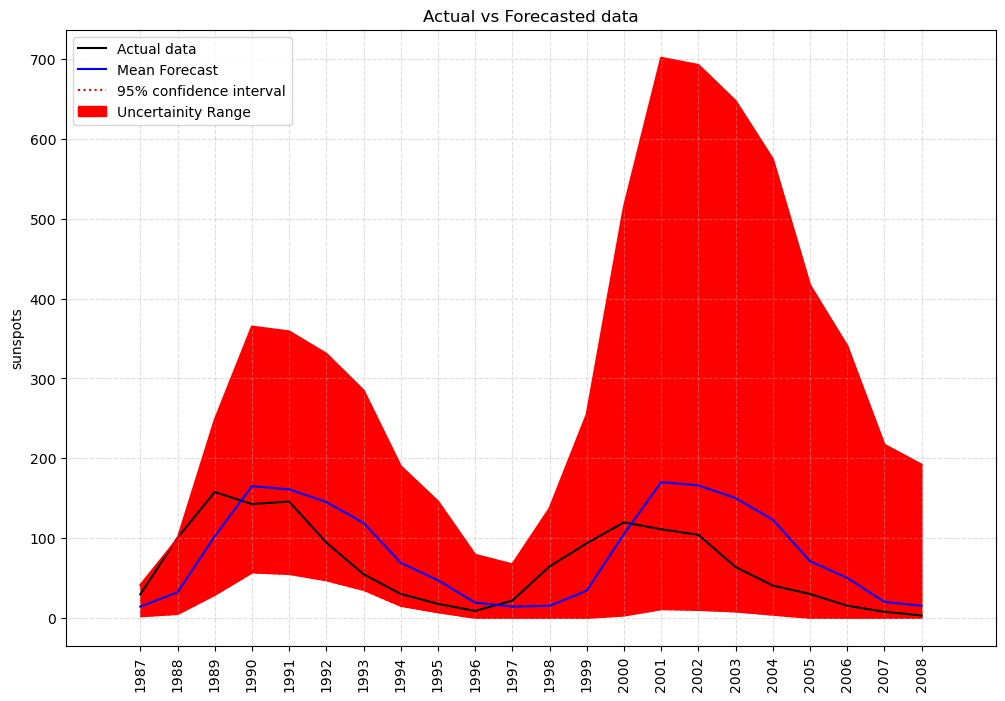

In [43]:
#plotting the forecasted data
plt.figure(figsize=(12,8))
plt.plot(testdf["YEAR"],testdf["SUNACTIVITY"],color="black",label="Actual data")
plt.plot(testdf['YEAR'],testdf["Mean_forecast"],color="blue",label="Mean Forecast")
plt.plot(testdf['YEAR'],testdf["lowerci_forecast"],color="red",linestyle=':',label="95% confidence interval")
plt.plot(testdf['YEAR'],testdf["upperci_forecast"],color="red")
plt.fill_between(testdf['YEAR'],testdf["upperci_forecast"],testdf["lowerci_forecast"],color="red",label="Uncertainity Range")
plt.xticks(np.arange(testdf['YEAR'].min(), testdf['YEAR'].max() + 1, 1))
plt.grid(True,linestyle="--",alpha=0.4)
plt.title("Actual vs Forecasted data")
plt.ylabel("sunspots")
plt.legend(loc="upper left")
plt.xticks(rotation=90,ha='center')
plt.xlim(testdf['YEAR'].min()-2,testdf['YEAR'].max()+2)
plt.savefig('Sunspot_forecast_plot.png',dpi=300)
plt.show()

Conclusion:
The AR(2) model successfully forecasted sunspot data within actual data scales and captured solar mimima very well.Although, we supposed a fixed 11 year seasonal pattern, the seasonal pattern is varied from 9-12 years due to irregular nature of solar cycles. A fixed 11 year historical window caused a phase shift in long horizons (2002 peak). Model can be further improved by using dynamic model, that incorporates seasonal shift.